<a href="https://colab.research.google.com/github/jyotipriyasarkar119-hue/AI-powered-Smart-Irrigation/blob/main/Smart_Irrigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Code you have previously used to load data
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor


In [2]:
from google.colab import files

uploaded = files.upload()

Saving rice_irrigation_dataset_v2.csv to rice_irrigation_dataset_v2.csv


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'rice_irrigation_dataset_v2.csv', 'sample_data']


In [5]:
import os

csv_files = [
    f for f in os.listdir("/content")
    if f.lower().endswith(".csv")
]

print("CSV files found:")
for f in csv_files:
    print(f)

CSV files found:
rice_irrigation_dataset_v2.csv


In [6]:
import pandas as pd

FILE_NAME = "rice_irrigation_dataset_v2.csv"

df = pd.read_csv(FILE_NAME)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (100000, 8)


,temperature,humidity,soil_moisture,rainfall,rain_probability,forecast_temperature,forecast_humidity,pump_state
0,31.4,82.9,74.9,1.4,46,34.3,83.3,0
1,25.3,85.5,50.4,0.8,39,26.5,81.6,1
2,33.4,80.2,19.8,2.2,56,34.7,77.2,1
3,34.2,84.9,18.6,0.1,54,34.8,91.3,1
4,21.2,95.2,13.5,0.1,70,18.4,89.1,1


In [7]:
FEATURES = [
    'temperature',
    'humidity',
    'soil_moisture',
    'rainfall',
    'rain_probability',
    'forecast_temperature',
    'forecast_humidity'
]

TARGET = 'pump_state'

X = df[FEATURES]
y = df[TARGET]

In [8]:
from sklearn.model_selection import train_test_split

# Split dataset into training and validation data
train_X, val_X, train_y, val_y = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features :", train_X.shape)
print("Validation features:", val_X.shape)
print("Training target   :", train_y.shape)
print("Validation target :", val_y.shape)

Training features : (80000, 7)
Validation features: (20000, 7)
Training target   : (80000,)
Validation target : (20000,)


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Specify Model
irrigation_model = RandomForestClassifier(
    n_estimators=5000,
    max_depth=None,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fit Model
irrigation_model.fit(
    train_X,
    train_y
)

print("Random Forest training completed.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    6.3s
[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:   15.9s
[Parallel(n_jobs=-1)]: Done 752 tasks      | elapsed:   29.5s
[Parallel(n_jobs=-1)]: Done 1202 tasks      | elapsed:   47.8s
[Parallel(n_jobs=-1)]: Done 1752 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 2402 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 3152 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 4002 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 4952 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 6002 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 7152 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 8402 tasks      | elapsed:  5.5min
[Parallel(n_jobs=-1)]: Done 9752 tasks      | elapsed:  6.4min


Random Forest training completed.


[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  6.6min finished


In [12]:
train_X, val_X, train_y, val_y = train_test_split(
    X, y, random_state=1
)

In [14]:
from sklearn.model_selection import train_test_split

train_X, val_X, train_y, val_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

print("Training samples:", len(train_X))
print("Validation samples:", len(val_X))

Training samples: 80000
Validation samples: 20000


In [16]:
# Make predictions on validation data
val_predictions = irrigation_model.predict(val_X)

print("Validation prediction completed.")

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.3s
[Parallel(n_jobs=24)]: Done 752 tasks      | elapsed:    0.7s
[Parallel(n_jobs=24)]: Done 1202 tasks      | elapsed:    1.1s
[Parallel(n_jobs=24)]: Done 1752 tasks      | elapsed:    1.6s
[Parallel(n_jobs=24)]: Done 2402 tasks      | elapsed:    2.1s
[Parallel(n_jobs=24)]: Done 3152 tasks      | elapsed:    2.8s
[Parallel(n_jobs=24)]: Done 4002 tasks      | elapsed:    3.6s
[Parallel(n_jobs=24)]: Done 4952 tasks      | elapsed:    4.4s
[Parallel(n_jobs=24)]: Done 6002 tasks      | elapsed:    5.4s
[Parallel(n_jobs=24)]: Done 7152 tasks      | elapsed:    6.4s
[Parallel(n_jobs=24)]: Done 8402 tasks      | elapsed:    7.5s
[Parallel(n_jobs=24)]: Done 9752 tasks      | elapsed:    8.8s
[Parallel(n_jobs=24)]: Done 10000 out of

Validation prediction completed.


In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(val_y, val_predictions)
mse = mean_squared_error(val_y, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(val_y, val_predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.0674
MSE : 0.0674
RMSE: 0.2596150997149434
R²  : 0.7235688783507839


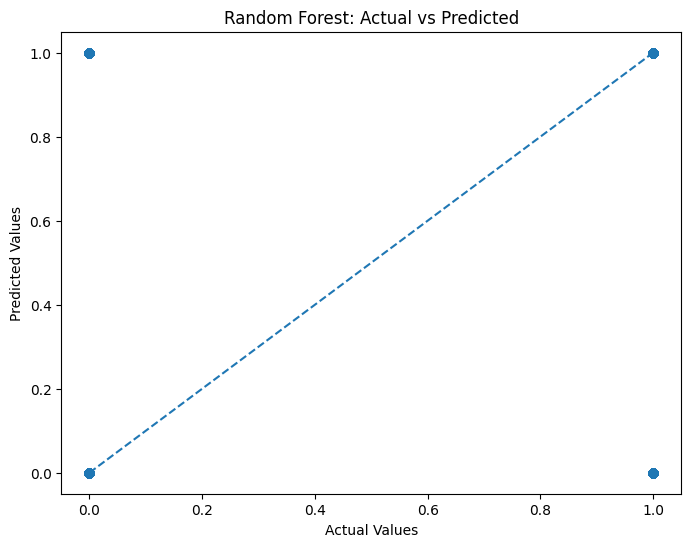

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(val_y, val_predictions, alpha=0.5)

# Perfect prediction line
plt.plot(
    [val_y.min(), val_y.max()],
    [val_y.min(), val_y.max()],
    linestyle="--"
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [19]:
train_predictions = irrigation_model.predict(train_X)

train_r2 = r2_score(train_y, train_predictions)
val_r2 = r2_score(val_y, val_predictions)

print("Training R²   :", train_r2)
print("Validation R² :", val_r2)

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.6s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    1.6s
[Parallel(n_jobs=24)]: Done 752 tasks      | elapsed:    3.0s
[Parallel(n_jobs=24)]: Done 1202 tasks      | elapsed:    4.6s
[Parallel(n_jobs=24)]: Done 1752 tasks      | elapsed:    6.6s
[Parallel(n_jobs=24)]: Done 2402 tasks      | elapsed:    9.0s
[Parallel(n_jobs=24)]: Done 3152 tasks      | elapsed:   11.9s
[Parallel(n_jobs=24)]: Done 4002 tasks      | elapsed:   14.8s
[Parallel(n_jobs=24)]: Done 4952 tasks      | elapsed:   18.0s
[Parallel(n_jobs=24)]: Done 6002 tasks      | elapsed:   21.6s
[Parallel(n_jobs=24)]: Done 7152 tasks      | elapsed:   25.7s
[Parallel(n_jobs=24)]: Done 8402 tasks      | elapsed:   30.1s
[Parallel(n_jobs=24)]: Done 9752 tasks      | elapsed:   35.2s


Training R²   : 0.7291083686047121
Validation R² : 0.7235688783507839


[Parallel(n_jobs=24)]: Done 10000 out of 10000 | elapsed:   36.2s finished


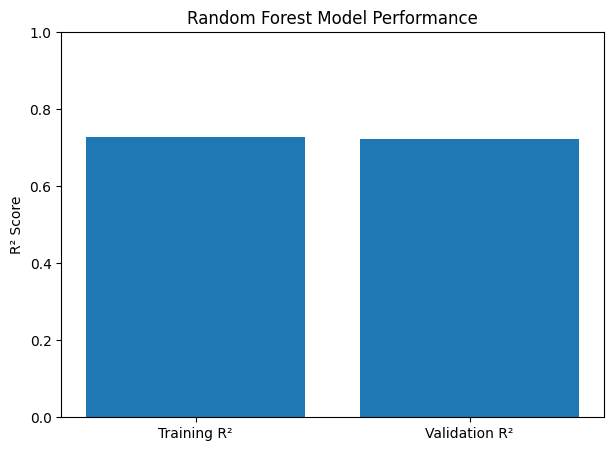

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    ["Training R²", "Validation R²"],
    [train_r2, val_r2]
)

plt.ylim(0, 1)
plt.ylabel("R² Score")
plt.title("Random Forest Model Performance")

plt.show()

In [21]:
val_predictions = irrigation_model.predict(val_X)

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.3s
[Parallel(n_jobs=24)]: Done 752 tasks      | elapsed:    0.6s
[Parallel(n_jobs=24)]: Done 1202 tasks      | elapsed:    1.1s
[Parallel(n_jobs=24)]: Done 1752 tasks      | elapsed:    1.6s
[Parallel(n_jobs=24)]: Done 2402 tasks      | elapsed:    2.1s
[Parallel(n_jobs=24)]: Done 3152 tasks      | elapsed:    2.8s
[Parallel(n_jobs=24)]: Done 4002 tasks      | elapsed:    3.6s
[Parallel(n_jobs=24)]: Done 4952 tasks      | elapsed:    4.4s
[Parallel(n_jobs=24)]: Done 6002 tasks      | elapsed:    5.4s
[Parallel(n_jobs=24)]: Done 7152 tasks      | elapsed:    6.4s
[Parallel(n_jobs=24)]: Done 8402 tasks      | elapsed:    7.6s
[Parallel(n_jobs=24)]: Done 9752 tasks      | elapsed:    8.8s
[Parallel(n_jobs=24)]: Done 10000 out of

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(val_y, val_predictions)
mse = mean_squared_error(val_y, val_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(val_y, val_predictions)

print("===== MODEL TEST RESULTS =====")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)

===== MODEL TEST RESULTS =====
MAE  : 0.0674
MSE  : 0.0674
RMSE : 0.2596150997149434
R²   : 0.7235688783507839


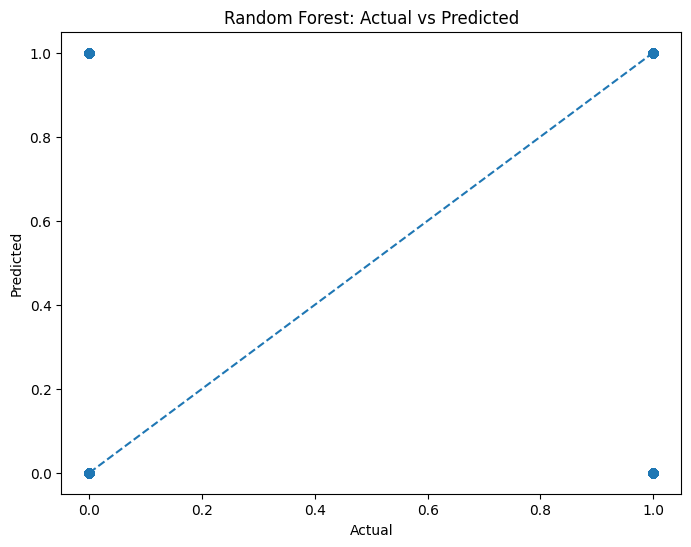

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(val_y, val_predictions, alpha=0.5)

plt.plot(
    [val_y.min(), val_y.max()],
    [val_y.min(), val_y.max()],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

In [26]:
import pandas as pd

new_data = pd.DataFrame({
    "soil_moisture": [35],
    "temperature": [30],
    "humidity": [65],
    "forecast_temperature": [29],
    "forecast_humidity": [70],
    "rain_probability": [20],
    "rainfall": [0],
    "pressure": [1008],
    "gas": [12000]
})

# Make absolutely sure the order is identical to training
new_data = new_data[irrigation_model.feature_names_in_]

prediction = irrigation_model.predict(new_data)

print("Predicted irrigation value:", prediction[0])

[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 752 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 1202 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 1752 tasks      | elapsed:    0.1s
[Parallel(n_jobs=24)]: Done 2402 tasks      | elapsed:    0.2s
[Parallel(n_jobs=24)]: Done 3152 tasks      | elapsed:    0.3s
[Parallel(n_jobs=24)]: Done 4002 tasks      | elapsed:    0.3s
[Parallel(n_jobs=24)]: Done 4952 tasks      | elapsed:    0.4s
[Parallel(n_jobs=24)]: Done 6002 tasks      | elapsed:    0.5s
[Parallel(n_jobs=24)]: Done 7152 tasks      | elapsed:    0.6s


Predicted irrigation value: 1


[Parallel(n_jobs=24)]: Done 8402 tasks      | elapsed:    0.8s
[Parallel(n_jobs=24)]: Done 9752 tasks      | elapsed:    0.9s
[Parallel(n_jobs=24)]: Done 10000 out of 10000 | elapsed:    0.9s finished


In [27]:
print(X.columns)

Index(['temperature', 'humidity', 'soil_moisture', 'rainfall',
       'rain_probability', 'forecast_temperature', 'forecast_humidity'],
      dtype='object')


In [28]:
from sklearn.ensemble import RandomForestClassifier

irrigation_model = RandomForestClassifier(
    n_estimators=200,
    random_state=1,
    n_jobs=-1
)

irrigation_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=1)

In [29]:
from sklearn.metrics import accuracy_score, classification_report

predictions = irrigation_model.predict(val_X)

accuracy = accuracy_score(val_y, predictions)

print("Accuracy:", accuracy)
print(classification_report(val_y, predictions))

Accuracy: 0.8572
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      8428
           1       0.88      0.88      0.88     11572

    accuracy                           0.86     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



In [30]:
import joblib

joblib.dump(irrigation_model, "irrigation_model.pkl")

print("Model exported successfully!")

Model exported successfully!


In [34]:
from google.colab import files

files.download("irrigation_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import joblib

model_package = {
    "model": irrigation_model,
    "features": list(irrigation_model.feature_names_in_)
}

joblib.dump(model_package, "irrigation_model_package.pkl")

print("Model + feature information exported!")
print("Features:", model_package["features"])

Model + feature information exported!
Features: ['temperature', 'humidity', 'soil_moisture', 'rainfall', 'rain_probability', 'forecast_temperature', 'forecast_humidity']


In [35]:
from google.colab import files

files.download("irrigation_model_package.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>